In [ ]:
using LinearAlgebra
using BSplineKit
using PyCall
using DelimitedFiles
using Plots
using NonlinearEigenproblems
using Printf
include("BaseFlow_cavity.jl")
include("Stability_Cavity.jl")

In [ ]:
LinearAlgebra.BLAS.set_num_threads(1)

In [ ]:
Res = 2000
N_cheb = 129
mode = 1
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0.2
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

In [ ]:
Res = 2000
N_cheb = 129
mode = 3
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0.0
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D_1,D2_1,z_1 = CRC_BF.Cheb(N_cheb,mode)
F_1,G_1,H_1 = CRC_BF.interp(u0,v0,w0,z_1,N_cheb,mode)

In [ ]:
(F[2] - F[1]) / (z[2] - z[1])

In [ ]:
writedlm("baseflow_cavity.dat",[z F G H D*F D*G D * H])

In [ ]:
# plot(z,D*F)
# plot!(z,D*G)
# plot!(z,D*H)
plot(z,F)
plot!(z,G)
plot!(z,H)

In [ ]:
plot(z_1,D2_1 * F_1)
plot!(z_1,D2_1 * -(G_1.+1))
plot!(z_1,D2_1 * H_1)
# plot(z_1,F_1)
# plot!(z_1,G_1)
# plot!(z_1,H_1)

In [ ]:
# writedlm("Reh=$(Res)_as=$Ts.dat",[z F G H])

In [ ]:
R = 500
be = -0.3
OMEGA = 8.0
omega = 0.195
c = 0.01
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= CRC_STA.assemble_mat(cof,D,D2,be,omega,R)     
L0,L1,L2 = CRC_STA.boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-14)
vel = CRC_STA.eig_full(eigvec,N_cheb,1)
@show eigval

In [80]:
R = 495
be = 0.0
alpha = 0.3
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
C = eigen(H0,H1)
val = C.values
vec = C.vectors
map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.05, val)
val_filter0 = val[map_index0]
vec_filter0 = vec[:,map_index0]
indictor = sum(real(val_filter0))/length(val_filter0)
map_index = map(x-> (real(x)) > indictor + 0.01 , val_filter0)
val_filter = val_filter0[map_index]
vec_filter = vec_filter0[:,map_index]
val_target = val_filter[findmax(imag.(val_filter))[2]]
vec_target = vec_filter[:,findmax(imag.(val_filter))[2]];
val_target

0.03219545870966581 + 0.0006784675191872629im

In [69]:
val_target

0.02633984917854822 + 0.002269925825139682im

In [64]:
indictor

-2.2112863466098726e-5

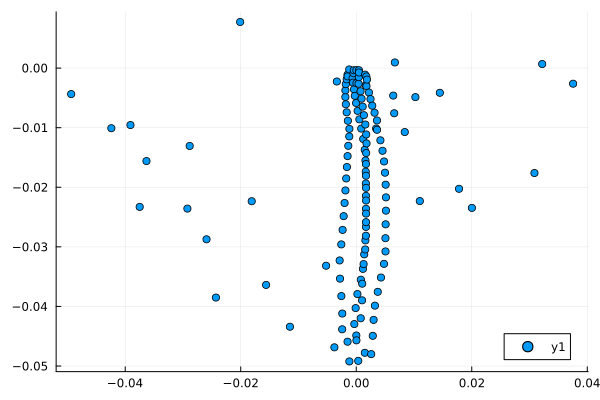

In [81]:
Plots.scatter(real(val_filter0),imag(val_filter0))

In [ ]:
function EigenCore(cof,D,D2,be,alpha,R,N_cheb)
    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
    C = eigen(H0,H1)
    val = C.values
    vec = C.vectors
    map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.5, val)
    val_filter0 = val[map_index0]
    vec_filter0 = vec[:,map_index0]
    indictor = sum(real(val_filter0))/length(val_filter0)
    map_index = map(x-> (real(x)) > indictor + 0.005 , val_filter0)
    val_filter = val_filter0[map_index]
    vec_filter = vec_filter0[:,map_index]
    val_target = val_filter[findmax(imag.(val_filter))[2]]
    vec_target = vec_filter[:,findmax(imag.(val_filter))[2]];
    return val_target,vec_target
end

In [ ]:
using Base.Threads
Threads.nthreads()

In [ ]:
function interation(R_ini, R_end, alpha_ini, alpha_end, be_up, be_down, N_cheb)
    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(1000,-1,0.0,1)
    D,D2,z = CRC_BF.Cheb(N_cheb,1)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,1)
    be_pos_range = 0.005 : 0.005 : be_up
    be_neg_range = -0.005 : -0.005 : be_down
    N_total_steps = 1 + length(be_pos_range) + length(be_neg_range)

    idx_root = length(be_neg_range) + 1
    open("test.dat", "w") do io

        for R = R_ini : 5 : R_end
            cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2, 1000)

            for alpha = alpha_ini  : 0.025 : alpha_end
                results_mat = zeros(Float64, N_total_steps, 5)

                val_root,vec_root = EigenCore(cof,D,D2,0.0,alpha,R,N_cheb)
                results_mat[idx_root, :] .= (R, alpha, 0.0, real(val_root), imag(val_root))                
                
                val, vec = val_root, vec_root
                for (i, be) in enumerate(be_pos_range)
                    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                    val,vec = rayleigh_quotient_iteration(H0,H1,val, vec)
                    results_mat[idx_root + i, :] .= (R, alpha, be, real(val), imag(val))              
                end
                val, vec = val_root, vec_root
                for (i, be) in enumerate(be_neg_range)
                    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                    val,vec = rayleigh_quotient_iteration(H0,H1,val, vec)
                    results_mat[idx_root - i, :] .= (R, alpha, be, real(val), imag(val))
                end
                
                writedlm(io,current_alpha_results)
                flush(io)
            end
        end
    end
end

In [ ]:
TITLE = "Flow Field Visualization"
VARIABLES = "X", "Y", "Z", "U" ,"V" 
ZONE T="Step_01", I=1, J=121, K=29, F=POINT

In [ ]:
R_ini= 500
R_end = 500
be_up = 0.3
be_down = -0.3
alpha_ini = 0.001
alpha_end = 0.71
N_cheb = 129
interation(R_ini, R_end, alpha_ini, alpha_end, be_up, be_down, N_cheb)

In [ ]:
data = readdlm("test.dat")
Plots.scatter(data[:,3],data[:,5])

In [ ]:
function rayleigh_quotient_iteration(A, B, sigma, q0=rand(size(A, 1), 1))

    flg = true
    i=1
    while flg
        i=i+1
        sigma0 = real(sigma[1]) + abs(imag(sigma[1]))im + 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end
        if i==20
            flg=false
        end
    end

      return sigma, q0
end